In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [ ]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c state-farm-distracted-driver-detection

 99% 3.96G/4.00G [02:30<00:01, 32.6MB/s]
100% 4.00G/4.00G [02:30<00:00, 28.6MB/s]


In [ ]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [ ]:
import os

print(os.listdir("/content/data/imgs/train"))

['c5', 'c7', 'c8', 'c4', 'c0', 'c1', 'c2', 'c6', 'c3', 'c9']


In [ ]:
import shutil
import random
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.layers import Dense
import matplotlib.pyplot as plt

In [ ]:
# paths
SOURCE_TRAIN_DIR = "/content/data/imgs/train"
PROCESSED_DIR = "/content/data/processed"

CLASS_NAMES = ["c0","c1","c2","c3","c4","c5","c6","c7","c8","c9"]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

RANDOM_SEED = 42

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [ ]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [ ]:
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        create_dir(os.path.join(PROCESSED_DIR, split, cls))

In [ ]:
# data split
random.seed(RANDOM_SEED)

for cls in CLASS_NAMES:
    cls_path = os.path.join(SOURCE_TRAIN_DIR, cls)
    images = [img for img in os.listdir(cls_path) if img.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "test", cls, img)
        )

    print(f"{cls}: {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

c0: 1493 train | 498 val | 498 test
c1: 1360 train | 453 val | 454 test
c2: 1390 train | 463 val | 464 test
c3: 1407 train | 469 val | 470 test
c4: 1395 train | 465 val | 466 test
c5: 1387 train | 462 val | 463 test
c6: 1395 train | 465 val | 465 test
c7: 1201 train | 400 val | 401 test
c8: 1146 train | 382 val | 383 test
c9: 1277 train | 426 val | 426 test


In [ ]:
def count_images(split):
    total = 0
    for cls in CLASS_NAMES:
        total += len(os.listdir(os.path.join(PROCESSED_DIR, split, cls)))
    return total

print("Train images:", count_images("train"))
print("Val images:", count_images("val"))
print("Test images:", count_images("test"))

Train images: 13451
Val images: 4483
Test images: 4490


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Found 13451 files belonging to 10 classes.
Found 4483 files belonging to 10 classes.
Found 4490 files belonging to 10 classes.


In [ ]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (16, 224, 224, 3)
Labels shape: (16, 10)


**Simple CNN Model 1**

In [ ]:
def simple_cnn1(input_shape=(224,224,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Normalization
    x = layers.Rescaling(1./255)(inputs)

    # Block 1
    x = layers.Conv2D(12, (5,5), padding="same", activation="relu")(x)
    x = layers.Conv2D(12, (5,5), padding="same", activation="relu")(x)
    x = layers.AveragePooling2D((2,2))(x)

    # Flatten
    x = layers.Flatten()(x)

    # Dense
    x = layers.Dense(num_classes)(x)

    # Softmax
    outputs = layers.Softmax()(x)

    model = models.Model(inputs, outputs, name="Simple_CNN_1")
    return model

In [ ]:
model1 = simple_cnn1()
model1.summary()

Model: "Simple_CNN_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 12)   │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 12)   │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 12)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │     1,505,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,509,814 (5.76 MB)

 Trainable params: 1,509,814 (5.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.5746 - loss: 1.3137 - val_accuracy: 0.9835 - val_loss: 0.0823
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9858 - loss: 0.0643 - val_accuracy: 0.9837 - val_loss: 0.0659
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9936 - loss: 0.0303 - val_accuracy: 0.9920 - val_loss: 0.0296
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - accuracy: 0.9983 - loss: 0.0085 - val_accuracy: 0.9917 - val_loss: 0.0319
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9996 - loss: 0.0038 - val_accuracy: 0.9931 - val_loss: 0.0254
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 0.9888 - val_loss: 0.0441
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9974 - loss: 0.0095 - val_accuracy: 0.9938 - val_loss: 0.0226
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 1.0000 - loss: 2

In [ ]:
model1.save("/content/data/models/simple_cnn_1.keras")

In [ ]:
# Accuracy curve
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

NameError: name 'history1' is not defined

In [ ]:
# Loss curve
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

NameError: name 'history1' is not defined

In [ ]:
val_loss, val_acc = model1.evaluate(val_ds)
print("Validation Accuracy:", val_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9965 - loss: 0.0217
Validation Accuracy: 0.9928619265556335


In [ ]:
import time
import numpy as np

sample_batch = next(iter(val_ds))[0]

start = time.time()
pred = model1.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (ms):", time_per_image * 1000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Time per image (ms): 22.554069757461548


**Simple CNN Model 2**

In [ ]:
def simple_cnn2(input_shape=(224,224,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Normalization
    x = layers.Rescaling(1./255)(inputs)

    # Block 1
    x = layers.Conv2D(9, (3,3), padding="same", activation="relu")(x)
    x = layers.Conv2D(9, (3,3), padding="same", activation="relu")(x)
    x = layers.AveragePooling2D((2,2))(x)

    # Flatten
    x = layers.Flatten()(x)

    # Dense
    x = layers.Dense(num_classes)(x)

    # Softmax
    outputs = layers.Softmax()(x)

    model = models.Model(inputs, outputs, name="Simple_CNN_2")
    return model

In [ ]:
model2 = simple_cnn2()
model2.summary()

Model: "Simple_CNN_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 9)    │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 9)    │           738 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 9)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 112896)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │     1,128,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,129,960 (4.31 MB)

 Trainable params: 1,129,960 (4.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model2.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.5018 - loss: 1.5186 - val_accuracy: 0.9605 - val_loss: 0.1935
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9747 - loss: 0.1181 - val_accuracy: 0.9835 - val_loss: 0.0793
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9924 - loss: 0.0404 - val_accuracy: 0.9902 - val_loss: 0.0419
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9963 - loss: 0.0207 - val_accuracy: 0.9920 - val_loss: 0.0314
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9989 - loss: 0.0078 - val_accuracy: 0.9920 - val_loss: 0.0261
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9926 - val_loss: 0.0253
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9977 - loss: 0.0096 - val_accuracy: 0.9942 - val_loss: 0.0222
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 1.0000 - loss: 0

In [ ]:
model2.save("/content/data/models/simple_cnn_2.keras")

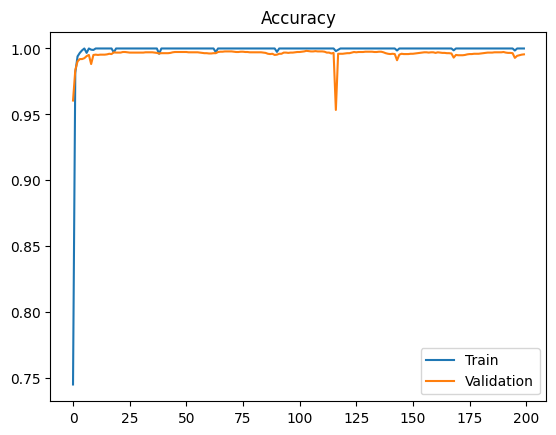

In [ ]:
# Accuracy curve
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

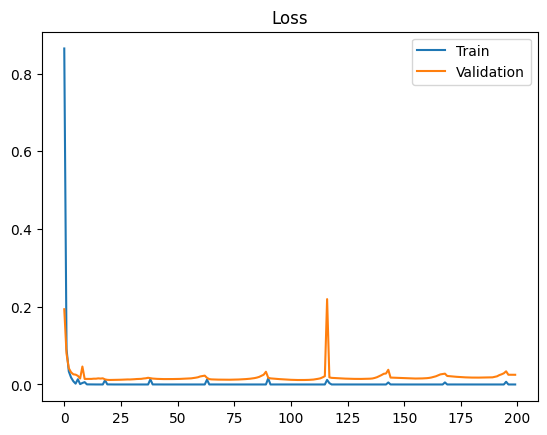

In [ ]:
# Loss curve
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
val_loss, val_acc = model2.evaluate(val_ds)
print("Validation Accuracy:", val_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9976 - loss: 0.0112
Validation Accuracy: 0.9955387115478516


In [ ]:
import time
import numpy as np

sample_batch = next(iter(val_ds))[0]

start = time.time()
pred = model2.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (ms):", time_per_image * 1000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Time per image (ms): 23.85781705379486


**Simple CNN Model 3**

In [ ]:
def simple_cnn3(input_shape=(224,224,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Normalization
    x = layers.Rescaling(1./255)(inputs)

    # Block 1
    x = layers.Conv2D(6, (3,3), padding="same", activation="relu")(x)
    x = layers.Conv2D(6, (3,3), padding="same", activation="relu")(x)
    x = layers.AveragePooling2D((2,2))(x)

    # Flatten
    x = layers.Flatten()(x)

    # Dense
    x = layers.Dense(num_classes)(x)

    # Softmax
    outputs = layers.Softmax()(x)

    model = models.Model(inputs, outputs, name="Simple_CNN_3")
    return model

In [ ]:
model3 = simple_cnn3()
model3.summary()

Model: "Simple_CNN_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 6)    │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 75264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       752,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 753,148 (2.87 MB)

 Trainable params: 753,148 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model3.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.4779 - loss: 1.6209 - val_accuracy: 0.9485 - val_loss: 0.2559
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9664 - loss: 0.1644 - val_accuracy: 0.9770 - val_loss: 0.1039
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.9881 - loss: 0.0627 - val_accuracy: 0.9846 - val_loss: 0.0650
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9957 - loss: 0.0291 - val_accuracy: 0.9891 - val_loss: 0.0432
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9964 - loss: 0.0176 - val_accuracy: 0.9868 - val_loss: 0.0458
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9989 - loss: 0.0086 - val_accuracy: 0.9888 - val_loss: 0.0377
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9984 - loss: 0.0075 - val_accuracy: 0.9906 - val_loss: 0.0371
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9995 - loss: 0

In [ ]:
model3.save("/content/data/models/simple_cnn_3.keras")

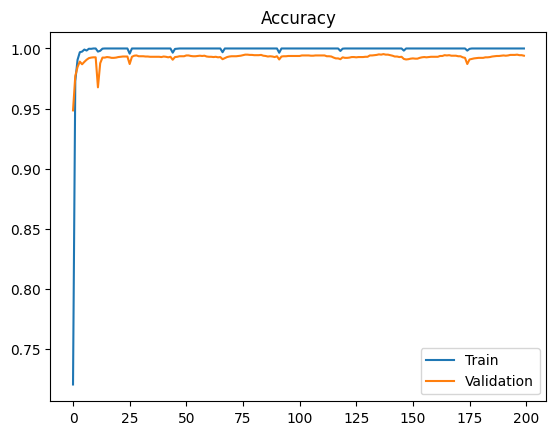

In [ ]:
# Accuracy curve
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

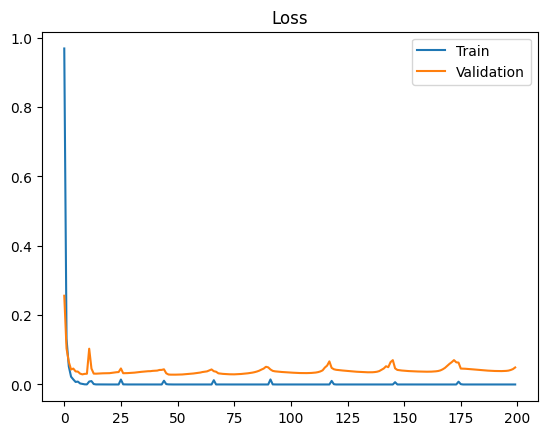

In [ ]:
# Loss curve
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
val_loss, val_acc = model3.evaluate(val_ds)
print("Validation Accuracy:", val_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9953 - loss: 0.0263
Validation Accuracy: 0.9939772486686707


In [ ]:
import time
import numpy as np

sample_batch = next(iter(val_ds))[0]

start = time.time()
pred = model3.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (ms):", time_per_image * 1000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
Time per image (ms): 23.765429854393005
